# MAE reconstruction quality check — `checkpoint_best.pt` (bellinzona_full_nir, 6ch, epoch 58)

This checkpoint is from the CORRECTED run (post compute_channel_stats fix) — loss
curve was healthy throughout (steady decline, no early plateau, train/val tracking
closely). This notebook loads it, runs a real tile through it, and plots original vs.
reconstructed side by side as a visual sanity check before building the downstream
linear-probe head on top of it.

CAVEAT: no bellinzona_full_nir tiles exist locally yet (that data lives only on the
HPC's /rs_scratch) — this uses an old lugano_example 6-channel tile instead, as a
quick smoke test. Mechanically compatible (same [NIR,R,G,B,NDVI,CHM] format, same
normalization approach) but not from the actual training AOI — treat this as a first
pass, not the final word; worth rerunning against a real bellinzona tile if this looks
ambiguous.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import load_tile, normalize, random_crop
from src.models.mae import MaskedAutoencoder, adapt_patch_embed
import timm

/Users/Aiden/Desktop/portfolio/palmTrack/files/ticino-palm-mapper/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load checkpoint and rebuild the model

In [2]:
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints_bellinzona" / "checkpoint_best.pt"

# Same architecture config used in src/training/pretrain_ssl.py's main() —
# must match exactly, since load_state_dict needs identical shapes.
BACKBONE_NAME = "vit_small_patch14_dinov2.lvd142m"
IN_CHANS = 6
IMG_SIZE = 224
PATCH_SIZE = 14
EMBED_DIM = 384
DECODER_EMBED_DIM = 192
DECODER_DEPTH = 4
DECODER_NUM_HEADS = 6
MASK_RATIO = 0.75

device = torch.device("cpu")  # inference-only, no need for GPU/MPS here

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
stats = checkpoint["stats"]
print(f"checkpoint epoch: {checkpoint['epoch']}")
print(f"stats mean: {stats.mean}, std: {stats.std}")

backbone = timm.create_model(BACKBONE_NAME, pretrained=False)  # weights get overwritten below
backbone = adapt_patch_embed(backbone, IN_CHANS)

model = MaskedAutoencoder(
    backbone, IMG_SIZE, PATCH_SIZE, IN_CHANS, EMBED_DIM,
    DECODER_EMBED_DIM, DECODER_DEPTH, DECODER_NUM_HEADS, MASK_RATIO,
)
model.backbone.patch_embed.strict_img_size = False
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
print("model loaded")

checkpoint epoch: 58
stats mean: [2.87067822e+03 1.00317287e+03 1.35448881e+03 1.45790940e+03
 4.22766927e-01 8.21381428e+00], std: [1.57769968e+03 8.61414284e+02 9.02106750e+02 8.38048208e+02
 2.99260683e-01 8.79518281e+00]


model loaded


## Load and preprocess one real tile

In [3]:
tile_dir = PROJECT_ROOT / "data/processed/lugano_example/feature_stack_rs"
tile_paths = sorted(tile_dir.glob("*_nirchm.tif"))
print(f"{len(tile_paths)} tiles available")

tile_path = tile_paths[0]  # change the index to look at a different tile
arr, transform, crs = load_tile(tile_path)
arr = normalize(arr, stats)

rng = np.random.default_rng(0)
crop, _ = random_crop(arr, np.zeros(arr.shape[1:]), IMG_SIZE, rng)  # dummy target, unused here

x = torch.from_numpy(crop).float().unsqueeze(0)  # (1, C, H, W)
print(f"input shape: {x.shape}")

36 tiles available


input shape: torch.Size([1, 6, 224, 224])


## Run inference

In [4]:
with torch.no_grad():
    loss, pred, mask = model(x)

print(f"reconstruction loss on this crop: {loss.item():.4f}")
print(f"pred shape: {pred.shape}, mask shape: {mask.shape}")

reconstruction loss on this crop: 0.1132
pred shape: torch.Size([1, 256, 1176]), mask shape: torch.Size([1, 256])


## Reconstruct images for visualization

`unpatchify` is the inverse of `MaskedAutoencoder.patchify` — same reshape/permute
logic, run backwards, to turn per-patch pixel vectors back into a (C, H, W) image.

Three panels: the original crop, a "masked" view (visible patches only, masked ones
blacked out, i.e. literally what the encoder saw), and the reconstruction (predicted
pixels at masked positions, original pixels at visible positions — standard MAE-paper
visualization, since the model was never asked to predict the visible patches).

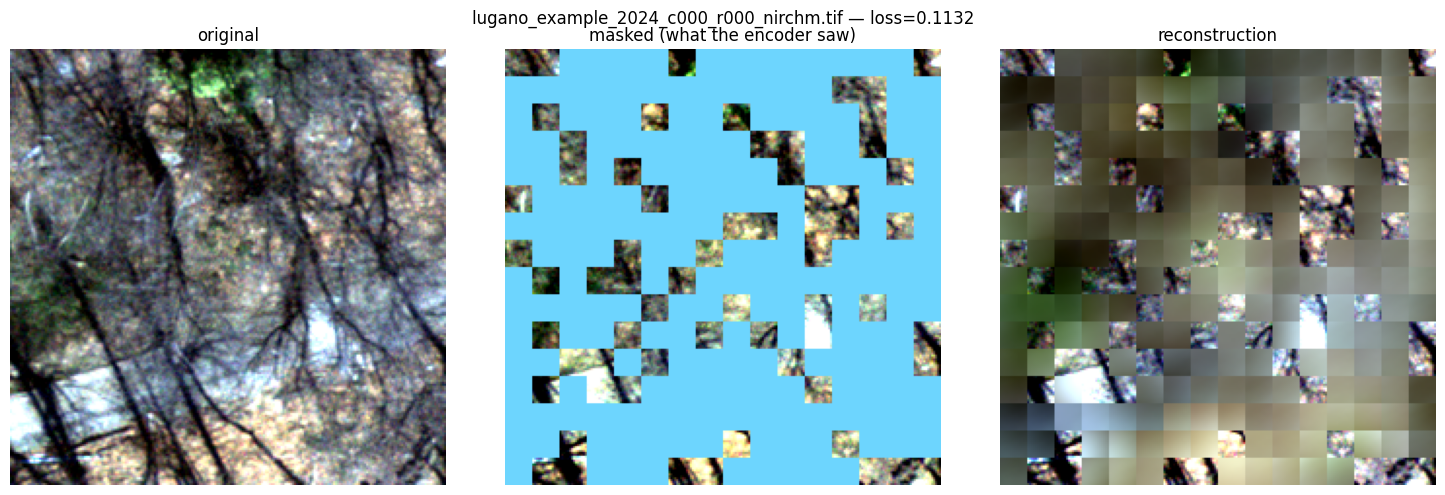

In [5]:
def unpatchify(tens: torch.Tensor, patch_size: int, h: int, w: int, C: int) -> torch.Tensor:
    B = tens.shape[0]
    p = patch_size
    tens = tens.reshape(B, h, w, p, p, C)
    tens = tens.permute(0, 5, 1, 3, 2, 4)
    tens = tens.reshape(B, C, h * p, w * p)
    return tens


h = w = IMG_SIZE // PATCH_SIZE

target_patches = model.patchify(x)  # (1, N, p*p*C) — ground truth in patch layout

# masked view: original pixels where visible (mask==0), zero where masked (mask==1)
masked_patches = target_patches * (1 - mask.unsqueeze(-1))

# reconstruction: predicted pixels where masked, original pixels where visible
recon_patches = pred * mask.unsqueeze(-1) + target_patches * (1 - mask.unsqueeze(-1))

original_img = unpatchify(target_patches, PATCH_SIZE, h, w, IN_CHANS)
masked_img = unpatchify(masked_patches, PATCH_SIZE, h, w, IN_CHANS)
recon_img = unpatchify(recon_patches, PATCH_SIZE, h, w, IN_CHANS)


def denorm_rgb(img: torch.Tensor) -> np.ndarray:
    """(1, C, H, W) normalized tensor -> (H, W, 3) uint8 RGB for display.

    Channel order here is [NIR,R,G,B,NDVI,CHM] (6ch stack) — R,G,B are
    channels 1:4, NOT 0:3 (that would be NIR,R,G, color-shifted).

    The RS-delivery R/G/B are NOT standard 8-bit (checkpoint stats show
    means in the ~1000-1500 range, not ~0-255 — likely a 12-bit+ sensor).
    A fixed clip(0,255) would blow every pixel out to white. Use a
    per-channel 2nd/98th-percentile contrast stretch instead, same
    approach already used in scripts/05_labeling_assist.py for this same
    RS-delivery data.
    """
    rgb_idx = slice(1, 4) if IN_CHANS == 6 else slice(0, 3)
    arr = img[0, rgb_idx].detach().numpy()
    mean = stats.mean[rgb_idx].reshape(3, 1, 1)
    std = stats.std[rgb_idx].reshape(3, 1, 1)
    arr = arr * std + mean  # undo normalize() -> back to raw sensor-count scale

    out = np.zeros_like(arr)
    for c in range(3):
        lo, hi = np.percentile(arr[c], (2, 98))
        out[c] = np.clip((arr[c] - lo) / (hi - lo + 1e-6), 0, 1) * 255
    return np.transpose(out.astype(np.uint8), (1, 2, 0))  # (H, W, C) for matplotlib


panels = [
    ("original", denorm_rgb(original_img)),
    ("masked (what the encoder saw)", denorm_rgb(masked_img)),
    ("reconstruction", denorm_rgb(recon_img)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"{tile_path.name} — loss={loss.item():.4f}")
plt.tight_layout()
plt.show()